## Load adata

In [2]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [33]:
region = 'cerebral_cortex' # Options: 'cerebral_cortex', 'hippocampus'
rev_n = 12 # Use 12
input_path = f"/home/ratopin/big_data/nmr/{region}_nmr_adata_optimal{rev_n}.h5ad"


In [34]:
adata = sc.read_h5ad(input_path)

## get clusters from `subcluster.ipynb`

In [35]:
clusters =pd.read_csv(f"../optimization/{region}_recursive_hpo_subclustering_labels.csv", index_col=0)
adata.obs['supercluster'] = clusters['supercluster']
adata.obs['cluster'] = clusters['cluster']
adata.obs['subcluster'] = clusters['subcluster']

In [36]:
print(f'Number of superclusters: {clusters['supercluster'].nunique()}')
print(f'Number of clusters: {clusters['cluster'].nunique()}')   
print(f'Number of subclusters: {clusters['subcluster'].nunique()}')

Number of superclusters: 3
Number of clusters: 32
Number of subclusters: 85


## Perform celltypist annotation (with custom model)

In [37]:
other_region = 'hippocampus' if region == 'cerebral_cortex' else 'cerebral_cortex'

In [38]:
model_path = f"../annotation/class_score_annotation/{region}_NMR_Brain_Custom_Model.pkl"
print(f"{model_path} Path OK") if os.path.exists(model_path) else print("File not found")

../annotation/class_score_annotation/cerebral_cortex_NMR_Brain_Custom_Model.pkl Path OK


In [39]:
from celltypist import models
model = models.Model.load(model_path)

In [40]:
print(adata.shape)
print(type(adata.X))

(24378, 17413)
<class 'numpy.ndarray'>


In [41]:
scores, probs, labels = model.predict_labels_and_prob(
    adata.X,
    mode='best match',
    p_thres=0.9999
)

In [42]:
probs.max(axis=1)

array([0.99999984, 0.99999962, 1.        , ..., 1.        , 0.99999999,
       0.99998376], shape=(24378,))

In [43]:
thres = 0.99999
len(labels[probs.max(axis=1) < thres])

4967

In [44]:
adata.obs['celltypist_prediction'] = labels
adata.obs['prediction_confidence'] = probs.max(axis=1)
adata.obs['reject_prediction'] = probs.max(axis=1) < thres

... storing 'cluster' as categorical
... storing 'subcluster' as categorical
... storing 'celltypist_prediction' as categorical


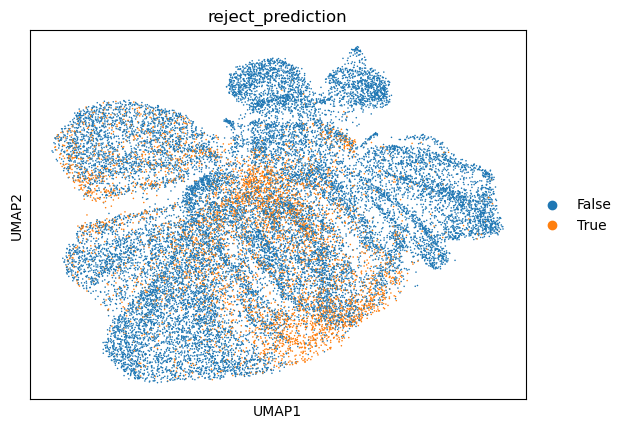

In [45]:
sc.pl.umap(adata, color='reject_prediction')

In [46]:
import pandas as pd

# ---------------------------------
# 1. Compute % rejected per subcluster
# ---------------------------------

total = adata.obs['subcluster'].value_counts()

rejected = (
    adata.obs.loc[
        adata.obs['reject_prediction'],
        'subcluster'
    ]
    .value_counts()
)

summary = pd.concat(
    [total, rejected],
    axis=1
).fillna(0)

summary.columns = [
    'total_cells',
    'rejected_cells'
]

summary['pct_rejected'] = (
    100
    * summary['rejected_cells']
    / summary['total_cells']
)

# mark low-confidence subclusters
low_conf_subclusters = set(
    summary.index[
        summary['pct_rejected'] > 15
    ]
)

print(
    f"Low-confidence subclusters: "
    f"{len(low_conf_subclusters)}"
)

# ---------------------------------
# 2. Initial labels
# ---------------------------------

adata.obs['traincell_final'] = (
    adata.obs['celltypist_prediction']
    .astype(str)
)

# add * only to low confidence subclusters
mask = adata.obs['subcluster'].isin(
    low_conf_subclusters
)

adata.obs.loc[
    mask,
    'traincell_final'
] = (
    adata.obs.loc[
        mask,
        'traincell_final'
    ]
    + '*'
)

# ---------------------------------
# 3. Collapse tiny groups (<50)
# inside each supercluster
# ---------------------------------

counts = (
    adata.obs
    .groupby(
        ['supercluster', 'traincell_final'],
        observed=True
    )
    .size()
    .reset_index(name='n_cells')
)

small = counts[
    counts['n_cells'] < 50
]

for _, row in small.iterrows():

    supercluster = row['supercluster']
    label = row['traincell_final']

    # toggle star
    if label.endswith('*'):
        replacement = label[:-1]
    else:
        replacement = label + '*'

    idx = (
        (adata.obs['supercluster'] == supercluster)
        &
        (adata.obs['traincell_final'] == label)
    )

    adata.obs.loc[
        idx,
        'traincell_final'
    ] = replacement

print(
    f"Collapsed {len(small)} "
    f"small groups (<50 cells)"
)

# inspect
adata.obs['traincell_final'].value_counts()

Low-confidence subclusters: 36


Collapsed 60 small groups (<50 cells)


traincell_final
Granular Neuron*                  7985
MGE Interneuron                   3095
Cajal-Retzius Cell*               2047
Ependymal*                        1982
Ependymal                         1835
Astrocyte*                        1573
Astrocyte                         1189
Oligodendrocyte Precursor Cell     812
Immature Neuron                    568
Immature Neuron*                   498
Granular Neuron                    279
Pyramidal Neuron*                  233
Astrocyte Precursor Cell           231
Endothelial Cell                   194
MGE Interneuron*                   192
CGE Interneuron                    186
Radial Glia                        166
LGE Interneuron                    157
Cajal-Retzius Cell                 149
Pericyte                           149
Oligodendrocyte                    145
Macrophage                         143
Neuroblast*                        123
Intermediate Progenitor Cell*      109
Microglia                          105
Microglia

In [47]:
import pandas as pd

# Total cells per subcluster
total = adata.obs['subcluster'].value_counts()

# Unassigned cells per subcluster
unassigned = (
    adata.obs
    .loc[adata.obs['reject_prediction'], 'subcluster']
    .value_counts()
)

# Merge
summary = pd.concat([total, unassigned], axis=1)
summary.columns = ['total_cells', 'unassigned_cells']
summary = summary.fillna(0)

# Percentage unassigned per subcluster
summary['pct_unassigned'] = (
    100
    * summary['unassigned_cells']
    / summary['total_cells']
)

# Select low-confidence subclusters
low_conf_subclusters = summary.index[
    summary['pct_unassigned'] > 15
]

print(
    f"Low-confidence subclusters ({len(low_conf_subclusters)}):",
    list(low_conf_subclusters)
)

# Create final labels
adata.obs['traincell_final'] = (
    adata.obs['celltypist_prediction']
    .astype(str)
)

# Append * to all cells belonging to low-confidence subclusters
mask = adata.obs['subcluster'].isin(low_conf_subclusters)

adata.obs.loc[
    mask,
    'traincell_final'
] = (
    adata.obs.loc[
        mask,
        'traincell_final'
    ]
    .str.rstrip('*') + '*'
)

# Optional summary
print(
    f"Cells relabeled as non-confident: {mask.sum()} "
    f"({100*mask.mean():.2f}%)"
)

Low-confidence subclusters (36): ['0/2', '0/3', '1/0', '0/0/0', '2/0', '0/1/0', '0/1/1', '0/0/2', '0/6', '0/1/2', '0/1/3', '2/2', '1/7', '0/5/1', '0/4/0', '0/4/1', '2/3', '0/4/2', '2/1/0', '2/4', '2/5', '2/1/1', '0/4/3', '0/1/4', '2/6', '2/1/2', '2/7', '2/1/3', '2/8', '0/5/3', '2/9', '0/1/5', '0/4/6', '2/1/4', '2/10', '2/1/5']
Cells relabeled as non-confident: 15507 (63.61%)


... storing 'traincell_final' as categorical


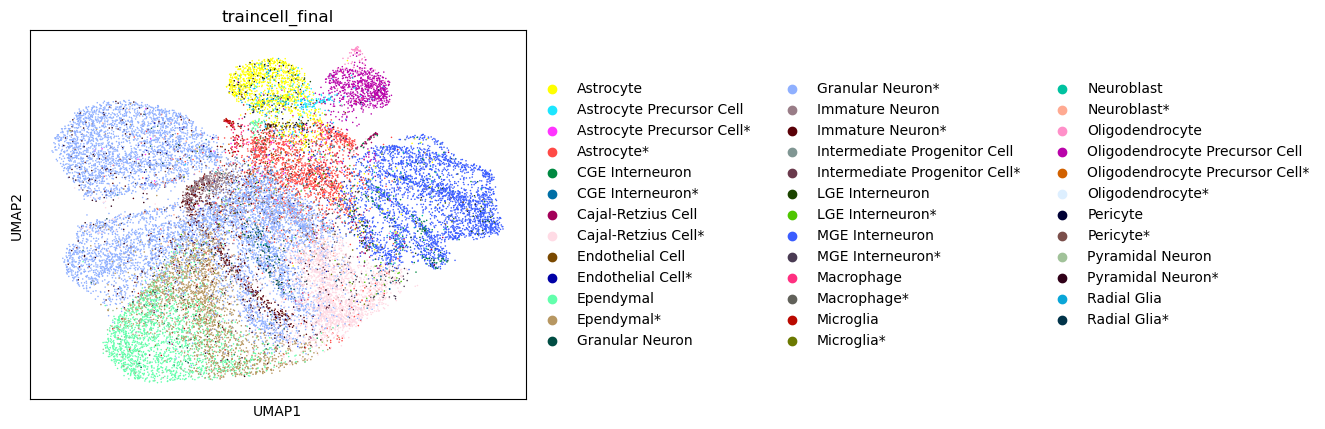

In [48]:
sc.pl.umap(adata, color=['traincell_final'], save=f'_{region}_traincell_final.png')

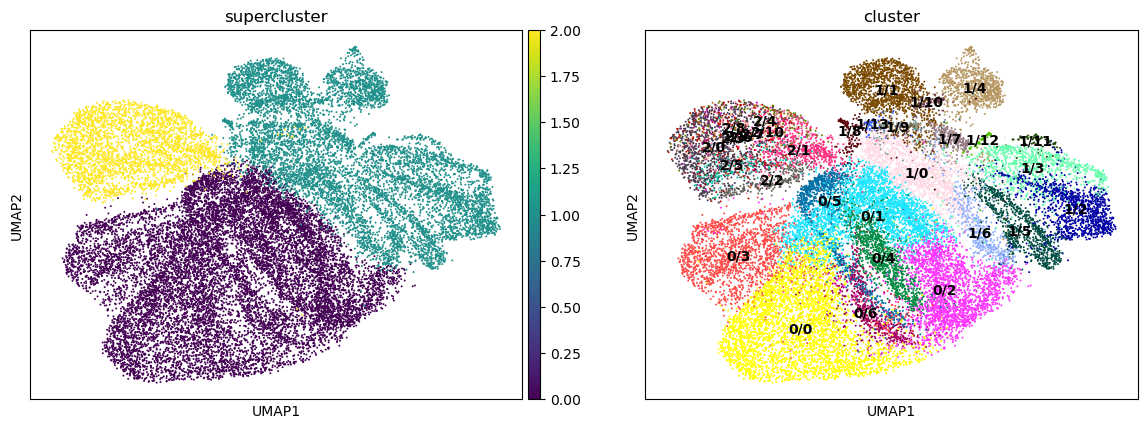

In [49]:
sc.pl.umap(adata, color=['supercluster', 'cluster'], save=f'_{region}_clusters.png', 
           legend_loc='on data', size=8)

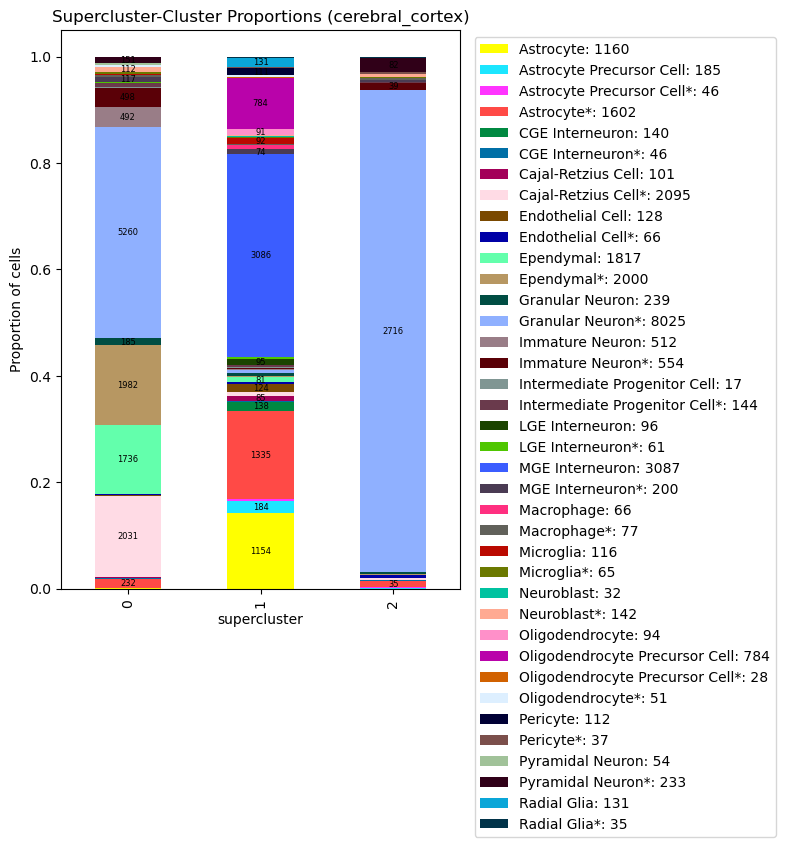

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. raw counts
counts = pd.crosstab(
    adata.obs['supercluster'],
    adata.obs['traincell_final']
)

# 2. proportions
proportions = counts.div(counts.sum(1), axis=0)

# 3. extract AnnData colors
cluster_order = list(counts.columns)

# scanpy stores colors aligned to adata.obs['cluster'].cat.categories
# but we map safely by category order
color_map = dict(zip(
    adata.obs['traincell_final'].cat.categories,
    adata.uns['traincell_final_colors']
))

# ensure alignment with plotted columns
colors = [color_map[c] for c in cluster_order if c in color_map]

# 4. plot with fixed colors
ax = proportions[cluster_order].plot(
    kind='bar',
    stacked=True,
    figsize=(8,8),
    color=colors,
    ylabel='Proportion of cells', 
    title=f"Supercluster-Cluster Proportions ({region})"
)

# 5. annotate absolute counts (cutoff 0.1)
for i, supercluster in enumerate(counts.index):
    bottom = 0

    for cluster in cluster_order:
        value = proportions.loc[supercluster, cluster]
        raw = counts.loc[supercluster, cluster]

        if raw == 0:
            continue

        if value < 0.008:
            bottom += value
            continue

        ax.text(
            i,
            bottom + value / 2,
            str(int(raw)),
            ha='center',
            va='center',
            fontsize=6
        )

        bottom += value

# 6. legend with total counts per cluster
handles, labels = ax.get_legend_handles_labels()

new_labels = [
    f"{label}: {counts[label].sum()}"
    for label in labels
]
ax.legend(
    handles,
    new_labels,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.savefig(f"{region}_supercluster_cluster_proportions.png", bbox_inches='tight')
plt.tight_layout()
plt.show()

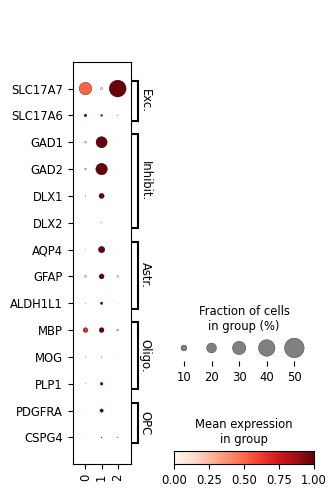

In [51]:
import scanpy as sc

marker_genes = {
    "Excitatory": ["SLC17A7", "SLC17A6"],
    "Inhibitory": ["GAD1", "GAD2", "DLX1", "DLX2"],
    "Astrocytes": ["AQP4", "GFAP", "ALDH1L1"],
    "Oligodendrocytes": ["MBP", "MOG", "PLP1"],
    "OPC": ["PDGFRA", "CSPG4"]
}

# flatten for scanpy
genes = [g for group in marker_genes.values() for g in group]
adata.obs["supercluster"] = adata.obs["supercluster"].astype(str)
adata.obs["supercluster"] = adata.obs["supercluster"].astype("category")
# dotplot
sc.pl.dotplot(
    adata,
    var_names=marker_genes,
    groupby="supercluster",
    standard_scale="var",   # makes markers comparable across genes
    dendrogram=False,
    swap_axes=True,
    cmap="Reds"
)

Missing genes (not in dataset):
{'Mature_Neuron': ['TUBB3'], 'Progenitor': ['MKI67']}


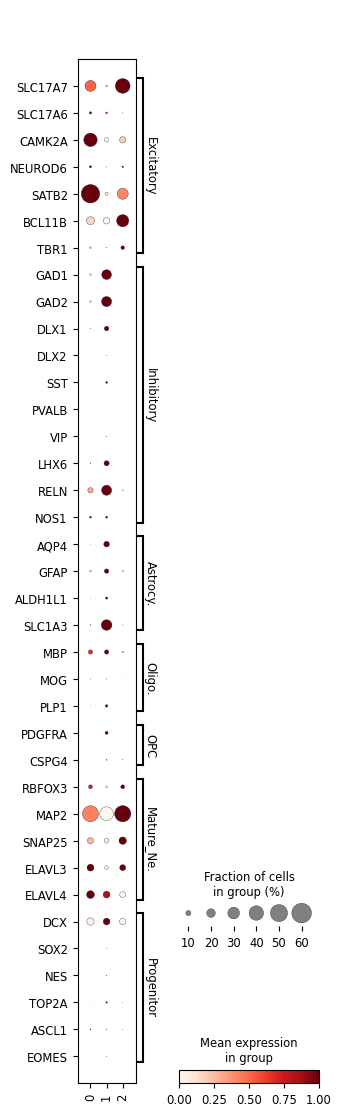

In [52]:
import scanpy as sc

extended_markers = {
    # Excitatory
    "Excitatory": [
        "SLC17A7", "SLC17A6",
        "CAMK2A", "NEUROD6", "SATB2", "BCL11B", "TBR1"
    ],

    # Inhibitory
    "Inhibitory": [
        "GAD1", "GAD2", "DLX1", "DLX2",
        "SST", "PVALB", "VIP", "LHX6", "RELN", "NOS1"
    ],

    # Astrocytes
    "Astrocytes": [
        "AQP4", "GFAP", "ALDH1L1", "SLC1A3"
    ],

    # Oligodendrocytes
    "Oligodendrocytes": [
        "MBP", "MOG", "PLP1"
    ],

    # OPC
    "OPC": [
        "PDGFRA", "CSPG4"
    ],

    # Neuronal maturity / identity
    "Mature_Neuron": [
        "RBFOX3", "MAP2", "TUBB3", "SNAP25",
        "ELAVL3", "ELAVL4"
    ],

    # Immature / progenitor
    "Progenitor": [
        "DCX", "SOX2", "NES", "MKI67", "TOP2A", "ASCL1", "EOMES"
    ]
}

# ----------------------------
# keep only genes present
# ----------------------------
filtered_markers = {
    group: [g for g in genes if g in adata.var_names]
    for group, genes in extended_markers.items()
}

# optional: print missing genes for debugging
missing = {
    group: [g for g in genes if g not in adata.var_names]
    for group, genes in extended_markers.items()
}

print("Missing genes (not in dataset):")
print({k: v for k, v in missing.items() if len(v) > 0})

# ----------------------------
# dotplot
# ----------------------------
sc.pl.dotplot(
    adata,
    var_names=filtered_markers,
    groupby="supercluster",
    standard_scale="var",
    swap_axes=True,
    cmap="Reds"
)

In [53]:
summary.head(10)

,total_cells,unassigned_cells,pct_unassigned
subcluster,,,
0/2,2270,956,42.114537
0/3,1726,324,18.771727
1/0,1460,282,19.315068
0/0/0,1260,268,21.269841
1/2,1158,21,1.813472
2/0,1073,270,25.163094
0/1/0,996,305,30.622490
0/0/1,955,69,7.225131
1/4,900,6,0.666667


## Validation

In [54]:
lineage_tb = pd.read_csv('../annotation/class_score_annotation/ratopin_annotations(Lineage_markers).csv')
celltype_tb = pd.read_csv('../annotation/class_score_annotation/ratopin_annotations(Cell-type_markers).csv')
celltype_tb

,parent,class,pos_markers,neg_markers
0,Glia,Astrocyte,"GFAP, SLC1A3, SLC1A2, AQP4, S100B, ALDH1L1, AG...","TOP2A, PDGFRA, SLC17A7, GAD1, STMN2, DCX"
1,Glia,Astrocyte Precursor Cell,"PTPRZ1,PAX6, HES1, SOX9, Vim, TOP2A, C5, FGFR3","PDGFRA, GFAP, RBFOX3, MBP"
2,Glia,Oligodendrocyte,"MBP,PLP1,MAG,MOG,CNP, BCAS1, NOVA1, LHFPL3, ITPR2","PDGFRA, GFAP, AQP4, TOP2A, PTPRZ1"
3,Glia,Oligodendrocyte Precursor Cell,"PDGFRA,PCDH15,SOX6,DSCAM,CSPG4,SOX10, OLIG2, B...","AQP4,GFAP,ALDH1L1,GJA1, MBP, PLP1, MOG, RBFOX3..."
4,Non-Neural,Microglia,"ITGAM, F13A1, MEF2C, TTL, SRGAP2, IBA1, P2RY1...","MRC1, GFAP, ALDH1L1, SLC17A7, GAD1"
5,Glia,Ependymal,"CFAP299, DNAH11, ZBBX, MLF1, FOXJ1, PIFO","SLC17A7,PDGFRB, GFAP, AQP4, RBFOX3, MBP"
6,Neural Stem Cell,Radial Glia,"PAX6, HES1, SOX2, NES, Vim, FABP7","DCX, MBP, PLP1, EOMES"
7,Neural Stem Cell,Intermediate Progenitor Cell,"EOMES, ASCL1, PPP1R17, PENK, HES6","PAX6, Vim, RBFOX3, SLC17A7, GAD1"
8,Neural Stem Cell,Neuroblast,"DCX, NNAT, STMN1, NCAM1, NTNG1, DLX1, DLX2, NE...","SOX2, NES, GFAP, SLC1A3, RBFOX3, SNAP25, SYT1,..."
9,Excitatory Neuron,Immature Neuron,"CCND2, NEUROD1, STMN2,STMN4, GAP43, CDKN1B, DC...","GFAP, SLC1A3, NES, EOMES, PCNA, MCM2-7, TYMS, ..."


In [55]:
def parse_markers(adata, marker_table: pd.DataFrame, top_hvg=5000):
    pos_markers = {}
    not_found_genes_overall = []

    if top_hvg is not None:
        var_names = set(adata.var_names[adata.var["highly_variable_rank"] <= top_hvg])  
    else:
        var_names = set(adata.var_names)

    for i,lst in enumerate(marker_table.pos_markers):
        found_genes = []
        not_found_genes = []
        if lst is not np.nan:
            for gene in lst.split(','):
                gene = gene.strip()
                if gene in var_names:
                    found_genes.append(gene)
                else:
                    not_found_genes.append(gene)
            
            pos_markers[marker_table['class'][i]] = found_genes
            not_found_genes_overall.extend(not_found_genes)
    print(f"Positive markers found in adata.var:")
    print(pos_markers)

    neg_markers = {}
    for i,lst in enumerate(marker_table.neg_markers):
        found_genes = []
        not_found_genes = []
        if lst is np.nan:
            neg_markers[marker_table['class'][i]] = []
            continue
        else:
            for gene in lst.split(','):
                gene = gene.strip()
                if gene in var_names:
                    found_genes.append(gene)
                else:
                    not_found_genes.append(gene)
            
            neg_markers[marker_table['class'][i]] = found_genes
            not_found_genes_overall.extend(not_found_genes)
    print(f"Negative markers found in adata.var:")
    print(neg_markers)
    print(f"Not found genes: {len(not_found_genes_overall)}")
    print(not_found_genes_overall)
    return pos_markers, neg_markers, not_found_genes_overall
    

In [56]:
lineage_pos_markers, lineage_neg_markers, _ = parse_markers(adata, lineage_tb, top_hvg=6000)

Positive markers found in adata.var:
{'Glia': ['GFAP', 'MBP', 'PLP1', 'AIF1', 'NES', 'PDGFRA'], 'Excitatory Neuron': ['SLC17A7', 'SLC17A6', 'CAMK2A', 'NEUROD6', 'TBR1'], 'Inhibitory Neuron': ['GAD2', 'GAD1', 'NKX2-1', 'LHX8', 'DLX2', 'ASCL1', 'GRIN3A'], 'Non-Neural': ['PECAM1', 'FLT1']}
Negative markers found in adata.var:
{'Glia': ['ENSHGLG00000010365', 'TUBB2B', 'NEFL'], 'Excitatory Neuron': ['SST', 'VIP', 'GAD2'], 'Inhibitory Neuron': ['SLC17A7', 'PROX1', 'SATB2'], 'Non-Neural': ['GFAP', 'Vim', 'PDGFRA', 'SLC17A7', 'GAD2', 'GAD1']}
Not found genes: 11
['SOX10', 'S100B', 'CD68', 'SOX2', 'RBFOX3', 'MAP2', 'NEFH', 'DCX', 'PVALB', 'RBFOX3', 'SOX10']


In [57]:
celltype_pos_markers, celltype_neg_markers, _ = parse_markers(adata, celltype_tb, top_hvg=6000)

Positive markers found in adata.var:
{'Astrocyte': ['GFAP', 'SLC1A3', 'SLC1A2', 'AQP4', 'ALDH1L1', 'FGFR3'], 'Astrocyte Precursor Cell': ['PTPRZ1', 'PAX6', 'HES1', 'SOX9', 'Vim', 'TOP2A', 'C5', 'FGFR3'], 'Oligodendrocyte': ['MBP', 'PLP1', 'MAG', 'MOG', 'CNP', 'BCAS1', 'NOVA1', 'LHFPL3', 'ITPR2'], 'Oligodendrocyte Precursor Cell': ['PDGFRA', 'PCDH15', 'SOX6', 'CSPG4', 'BCAN', 'GPR17', 'PTPRZ1'], 'Microglia': ['ITGAM', 'F13A1', 'MEF2C', 'TTL', 'P2RY12'], 'Ependymal': ['CFAP299', 'DNAH11', 'ZBBX', 'MLF1', 'PIFO'], 'Radial Glia': ['PAX6', 'HES1', 'NES', 'Vim', 'FABP7'], 'Intermediate Progenitor Cell': ['EOMES', 'ASCL1', 'PENK', 'HES6'], 'Neuroblast': ['STMN1', 'NTNG1', 'DLX1', 'DLX2', 'KITLG', 'NEUROD2', 'SOX11', 'DPYSL3'], 'Immature Neuron': ['CCND2', 'STMN2', 'STMN4', 'GAP43', 'CDKN1B', 'ELAVL4', 'DPYSL3'], 'Pyramidal Neuron': ['SLC17A7', 'TAFA1', 'MPPED1', 'ST6GALNAC5', 'PDE1A', 'SATB2', 'KCNQ5', 'EMX1', 'CUX1', 'BCL11B', 'RORB', 'GLS', 'FEZF2', 'CAMK2A'], 'Cajal-Retzius Cell': ['SLC17A

categories: Astrocyte, Astrocyte Precursor Cell, Astrocyte Precursor Cell*, etc.
var_group_labels: Astrocyte, Astrocyte Precursor Cell, Oligodendrocyte, etc.


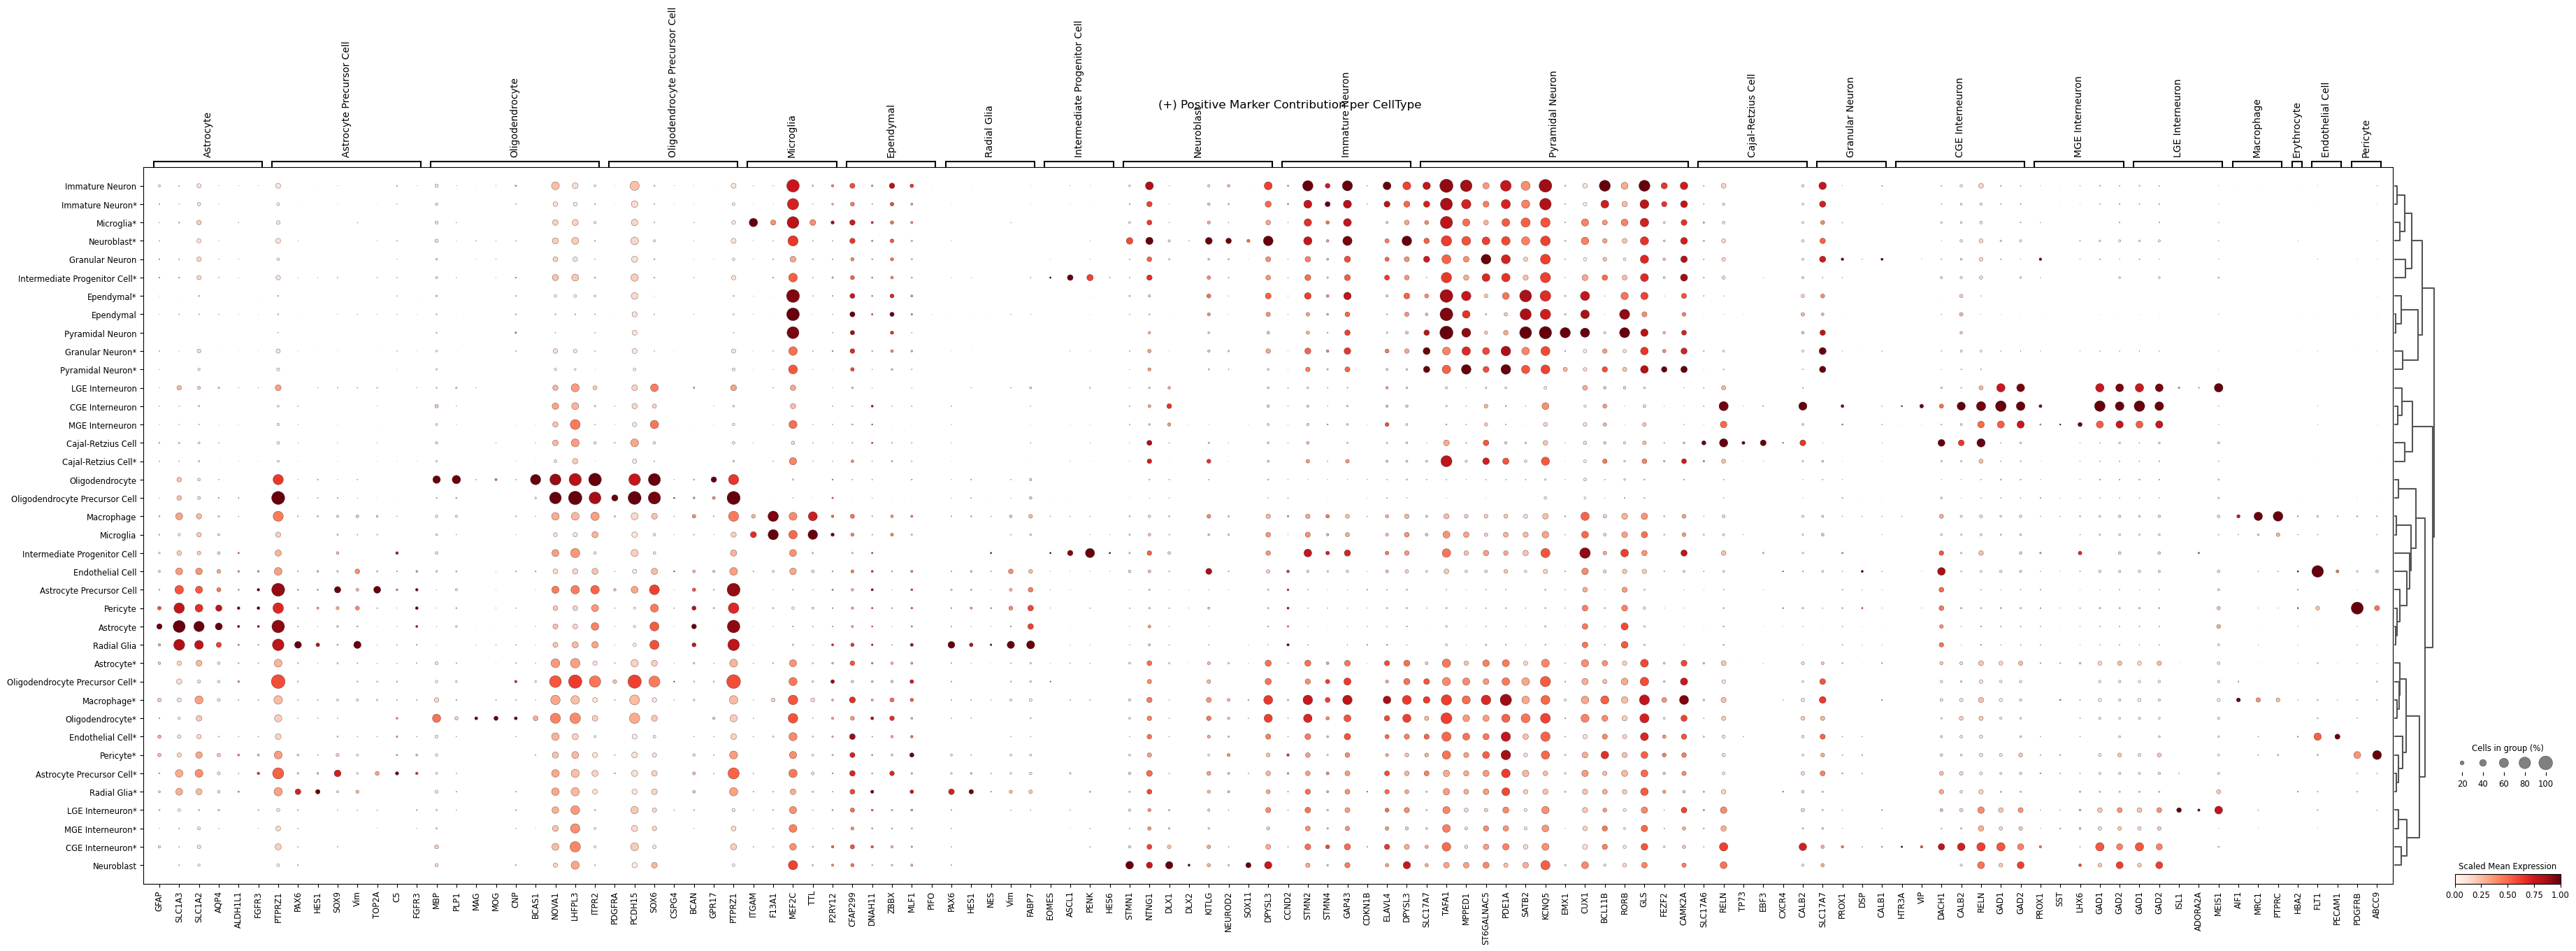

In [63]:
sc.pl.dotplot(
    adata, 
    celltype_pos_markers, 
    groupby='traincell_final', 
    standard_scale='var',  # Escala de 0 a 1 por gen para comparar mejor
    colorbar_title='Scaled Mean Expression',
    size_title='Cells in group (%)',
    expression_cutoff=0.05, # Oculta puntos con expresión despreciable
    dendrogram=True,        # Agrupa clústeres similares automáticamente
    title="(+) Positive Marker Contribution per CellType",
    swap_axes=False,
    save=f'{region}_positive_marker_contribution_per_celltype_final.png',
)

plt.show()


In [59]:
adata.obs['traincell_final'].to_csv(f'{region}_celltrain_predictions.csv')


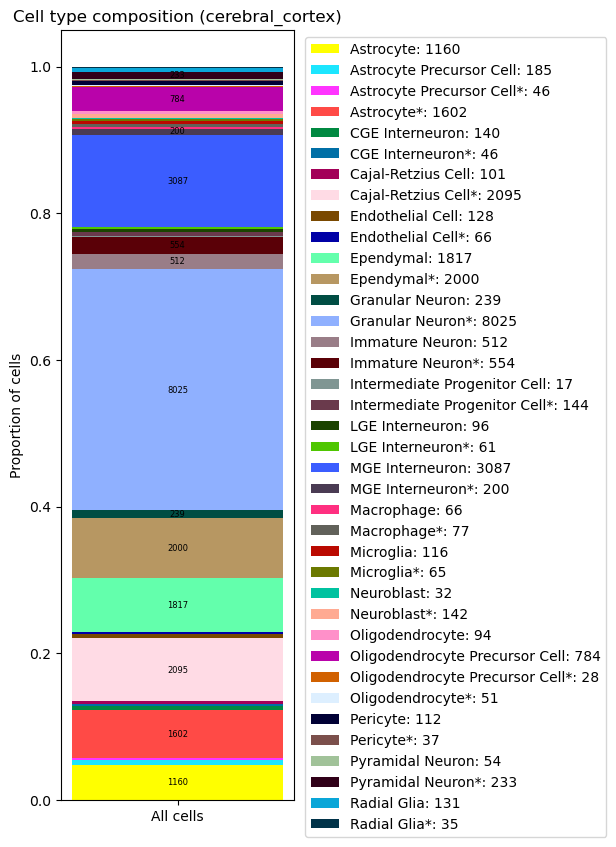

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Count cells per CellTypist prediction
counts = (
    adata.obs['traincell_final']
    .value_counts()
)

# preserve category order if categorical
cluster_order = [
    c for c in adata.obs['traincell_final'].cat.categories
    if c in counts.index
]

counts = counts.reindex(cluster_order)

# 2. Convert to proportions
proportions = counts / counts.sum()

# 3. Extract colors
color_map = dict(zip(
    adata.obs['traincell_final'].cat.categories,
    adata.uns['traincell_final_colors']
))

colors = [color_map[c] for c in cluster_order]

# 4. Plot one stacked bar
fig, ax = plt.subplots(figsize=(3, 10))

bottom = 0

for celltype, prop, raw, color in zip(
    cluster_order,
    proportions,
    counts,
    colors
):

    ax.bar(
        x=0,
        height=prop,
        bottom=bottom,
        color=color,
        width=0.8,
        label=celltype
    )

    # annotate counts
    if prop >= 0.008:
        ax.text(
            0,
            bottom + prop / 2,
            str(raw),
            ha='center',
            va='center',
            fontsize=6
        )

    bottom += prop

# 5. Formatting
ax.set_xticks([0])
ax.set_xticklabels(["All cells"])
ax.set_ylabel("Proportion of cells")
ax.set_title(f"Cell type composition ({region})")

# 6. Legend with total counts
handles, labels = ax.get_legend_handles_labels()

new_labels = [
    f"{label}: {counts[label]}"
    for label in labels
]

ax.legend(
    handles,
    new_labels,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(
    f"{region}_traincell_composition.png",
    bbox_inches="tight"
)
plt.show()

In [61]:
new_col = 'traincell_final'

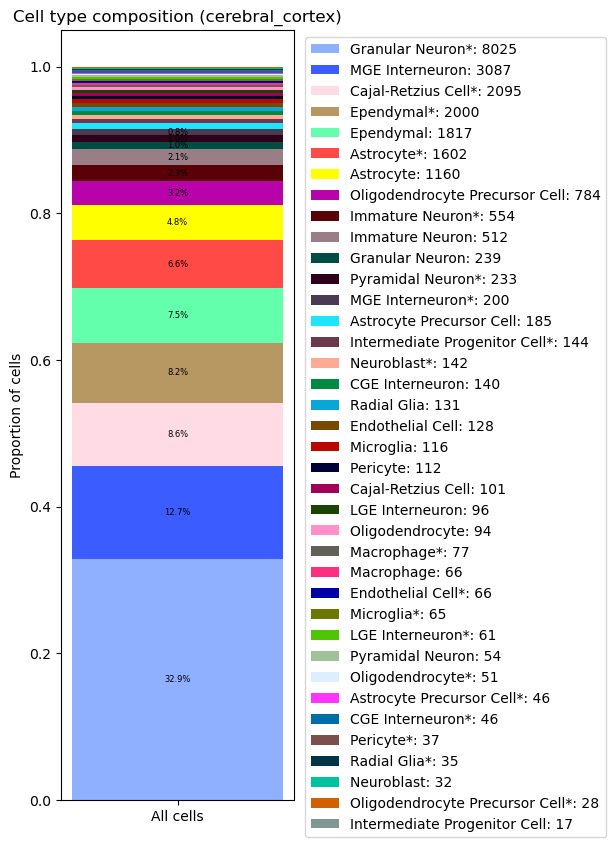

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Count cells and sort descending
counts = (
    adata.obs[new_col]
    .value_counts()
    .sort_values(ascending=False)
)

cluster_order = counts.index.tolist()

# 2. Convert to proportions
proportions = counts / counts.sum()

# 3. Extract colors preserving sorted order
color_map = dict(zip(
    adata.obs[new_col].cat.categories,
    adata.uns[f'{new_col}_colors']
))

# fallback if some labels are not categorical anymore
colors = [
    color_map.get(c, 'lightgray')
    for c in cluster_order
]

# 4. Plot one stacked bar
fig, ax = plt.subplots(figsize=(3, 10))

bottom = 0

for celltype, prop, raw, color in zip(
    cluster_order,
    proportions,
    counts,
    colors
):

    ax.bar(
        x=0,
        height=prop,
        bottom=bottom,
        color=color,
        width=0.8,
        label=celltype
    )

    # annotate percentage
    if prop >= 0.008:
        ax.text(
            0,
            bottom + prop / 2,
            f"{prop*100:.1f}%",
            ha="center",
            va="center",
            fontsize=6
        )

    bottom += prop

# 5. Formatting
ax.set_xticks([0])
ax.set_xticklabels(["All cells"])
ax.set_ylabel("Proportion of cells")
ax.set_title(f"Cell type composition ({region})")

# 6. Legend with counts (same order as stack)
handles, labels = ax.get_legend_handles_labels()

new_labels = [
    f"{label}: {counts[label]}"
    for label in labels
]

ax.legend(
    handles,
    new_labels,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    f"{region}_traincell_global_composition_sorted.png",
    bbox_inches="tight"
)

plt.show()

## get differentially expressed genes

In [151]:
import scanpy as sc

deg_results = {}

for sc_name in adata.obs['supercluster'].unique():

    # subset one supercluster
    sub = adata[
        adata.obs['supercluster'] == sc_name
    ].copy()

    # skip if only one celltype exists
    n_ct = sub.obs['traincell_final'].nunique()

    if n_ct < 2:
        print(f"Skipping {sc_name}: only {n_ct} celltype")
        continue

    print(f"Running DEGs for {sc_name}")

    # DE: each celltype vs other celltypes INSIDE this supercluster
    sc.tl.rank_genes_groups(
        sub,
        groupby='traincell_final',
        method='wilcoxon',
        reference='rest'
    )

    # Filter
    sc.tl.filter_rank_genes_groups(
        sub,
        groupby='traincell_final',
        min_fold_change=1.5,
        min_in_group_fraction=0.1
    )

    # store results
    deg_results[sc_name] = sub.uns['rank_genes_groups_filtered']

Running DEGs for 0


ValueError: Could not calculate statistics for groups CGE Interneuron since they only contain one sample.

In [ ]:
import pandas as pd

all_deg = []

for sc_name in deg_results:

    df = sc.get.rank_genes_groups_df(
        adata[adata.obs['supercluster'] == sc_name],
        group=None,
        key='rank_genes_groups_filtered'
    )

    df['supercluster'] = sc_name

    all_deg.append(df)

all_deg = pd.concat(all_deg, ignore_index=True)

all_deg.head()

In [ ]:
# Rank genes in the Unknown group vs others
sc.tl.rank_genes_groups(adata, groupby='traincell_final', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)